<a href="https://colab.research.google.com/github/Riyajha182005/Genai-from-scratch/blob/main/Kmeans_algorithm_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd


In [2]:
players=pd.read_csv("/content/players_22.csv.zip")

/tmp/ipython-input-99074267.py:1: DtypeWarning: Columns (25,108) have mixed types. Specify dtype option on import or set low_memory=False.
  players=pd.read_csv("/content/players_22.csv.zip")


In [3]:
players

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,...,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,...,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1353/60.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,...,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
3,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,...,50+3,50+3,50+3,62+3,20+3,https://cdn.sofifa.net/players/190/871/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,NaN,https://cdn.sofifa.net/flags/br.png
4,192985,https://sofifa.com/player/192985/kevin-de-bruy...,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,...,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/players/192/985/22_120.png,https://cdn.sofifa.net/teams/10/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1325/60.png,https://cdn.sofifa.net/flags/be.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19234,261962,https://sofifa.com/player/261962/defu-song/220002,Song Defu,宋德福,CDM,47,52,70000.0,1000.0,22,...,46+2,46+2,46+2,48+2,15+2,https://cdn.sofifa.net/players/261/962/22_120.png,https://cdn.sofifa.net/teams/112541/60.png,https://cdn.sofifa.net/flags/cn.png,NaN,https://cdn.sofifa.net/flags/cn.png
19235,262040,https://sofifa.com/player/262040/caoimhin-port...,C. Porter,Caoimhin Porter,CM,47,59,110000.0,500.0,19,...,44+2,44+2,44+2,48+2,14+2,https://cdn.sofifa.net/players/262/040/22_120.png,https://cdn.sofifa.net/teams/445/60.png,https://cdn.sofifa.net/flags/ie.png,NaN,https://cdn.sofifa.net/flags/ie.png
19236,262760,https://sofifa.com/player/262760/nathan-logue/...,N. Logue,Nathan Logue-Cunningham,CM,47,55,100000.0,500.0,21,...,45+2,45+2,45+2,47+2,12+2,https://cdn.sofifa.net/players/262/760/22_120.png,https://cdn.sofifa.net/teams/111131/60.png,https://cdn.sofifa.net/flags/ie.png,NaN,https://cdn.sofifa.net/flags/ie.png
19237,262820,https://sofifa.com/player/262820/luke-rudden/2...,L. Rudden,Luke Rudden,ST,47,60,110000.0,500.0,19,...,26+2,26+2,26+2,32+2,15+2,https://cdn.sofifa.net/players/262/820/22_120.png,https://cdn.sofifa.net/teams/111131/60.png,https://cdn.sofifa.net/flags/ie.png,NaN,https://cdn.sofifa.net/flags/ie.png


In [4]:
features=["overall","potential","wage_eur","value_eur","age"]

In [5]:
players=players.dropna(subset=features)

In [6]:
data=players[features].copy()

In [7]:
data

,overall,potential,wage_eur,value_eur,age
0,93,93,320000.0,78000000.0,34
1,92,92,270000.0,119500000.0,32
2,91,91,270000.0,45000000.0,36
3,91,91,270000.0,129000000.0,29
4,91,91,350000.0,125500000.0,30
...,...,...,...,...,...
19234,47,52,1000.0,70000.0,22
19235,47,59,500.0,110000.0,19
19236,47,55,500.0,100000.0,21
19237,47,60,500.0,110000.0,19


In [8]:
data.tail()

,overall,potential,wage_eur,value_eur,age
19234,47,52,1000.0,70000.0,22
19235,47,59,500.0,110000.0,19
19236,47,55,500.0,100000.0,21
19237,47,60,500.0,110000.0,19
19238,47,60,500.0,110000.0,19


# **1. Scale The Data**

**2.Intialise the random centroids**

**3.Label each data point**

**4.Update centroids**

**5.Repeat Step 3and 4 until centoids stop changing**

In [9]:
data=(data-data.min())/(data.max()-data.min())*9+1

The line `data=(data-data.min())/(data.max()-data.min())*9+1` performs a **Min-Max Scaling** (also known as normalization) on the `data` DataFrame, and then rescales the normalized values to a specific range.

Let's break it down:

1.  **`(data - data.min())`**: This subtracts the minimum value of each column in the `data` DataFrame from all values in that respective column. This shifts the minimum value of each column to 0.

2.  **`/(data.max() - data.min())`**: This divides the result from step 1 by the range (maximum value minus minimum value) of each column. After this step, the values in each column will be scaled to a range between 0 and 1.

    *   Formula for Min-Max Scaling (0 to 1): `(x - min(x)) / (max(x) - min(x))`

3.  **`*9`**: The result (values between 0 and 1) is then multiplied by 9. This stretches the range from 0-1 to 0-9.

4.  **`+1`**: Finally, 1 is added to all values. This shifts the entire range from 0-9 to 1-10.

In summary, this operation scales all numerical features in the `data` DataFrame so that their values fall within the range of 1 to 10.

In [10]:
data.describe()

,overall,potential,wage_eur,value_eur,age
count,19165.000000,19165.000000,19165.000000,19165.000000,19165.000000
mean,4.670472,5.319998,1.219443,1.131826,4.063345
std,1.346635,1.191076,0.501528,0.353229,1.575838
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.739130,4.521739,1.012876,1.021620,2.666667
50%,4.717391,5.304348,1.064378,1.044817,4.000000
75%,5.500000,6.086957,1.193133,1.092370,5.333333
max,10.000000,10.000000,10.000000,10.000000,10.000000


In [11]:
data.head()


,overall,potential,wage_eur,value_eur,age
0,10.000000,9.608696,9.227468,4.618307,7.000000
1,9.804348,9.413043,7.939914,6.543654,6.333333
2,9.608696,9.217391,7.939914,3.087308,7.666667
3,9.608696,9.217391,7.939914,6.984396,5.333333
4,9.608696,9.217391,10.000000,6.822018,5.666667


# **2.Intialise the random centroids**

The line `centroid=data.apply(lambda x:float(x.sample()))` is used to initialize a single centroid for a clustering algorithm, such as K-Means. Here's what each part does:

1.  **`data.apply(...)`**: This method applies a function along an axis of the DataFrame. By default, it applies the function to each column of `data` individually. So, `x` in the `lambda` function will represent each column (as a pandas Series) of your `data` DataFrame.

2.  **`x.sample()`**: For each column `x`, this takes a single random sample from that column. This effectively picks a random data point's value for that specific feature.

3.  **`float(...)`**: The `x.sample()` method returns a pandas Series (even if it contains only one value). The `float()` conversion extracts the numerical value from this single-element Series.

In summary, this line creates a new Series called `centroid`. Each element in `centroid` corresponds to a feature (column) in your `data` DataFrame and holds a randomly selected value from that feature's range. This is a common way to randomly initialize the starting position of a centroid for algorithms that require them, ensuring the centroid starts within the data's observed value ranges for each feature.

In [12]:
def random_centroids(data,k):
 centroids=[]
 for i in range(k):
  centroid=data.apply(lambda x:float(x.sample()))
  centroids.append(centroid)
 return pd.concat(centroids,axis=1)

In [13]:
centroids=random_centroids(data,5)

/tmp/ipython-input-301656181.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  centroid=data.apply(lambda x:float(x.sample()))


In [14]:
centroids

,0,1,2,3,4
overall,4.717391,4.717391,5.500000,3.347826,5.108696
potential,5.695652,5.304348,4.326087,7.652174,5.695652
wage_eur,1.527897,1.000000,1.038627,1.000000,1.064378
value_eur,1.011181,1.148043,1.106288,1.041337,1.014660
age,2.333333,4.000000,3.666667,5.333333,2.333333


In [15]:
def get_labels(data,centroids):
  distances=centroids.apply(lambda x:np.sqrt(((data-x)**2).sum(axis=1)))
  return distances.idxmin(axis=1)

In [16]:
labels=get_labels(data,centroids)

In [ ]:
labels

,0
0,2
1,3
2,2
3,3
4,3
...,...
19234,0
19235,0
19236,0
19237,0


In [17]:
labels.value_counts()

,count
1,11905
0,4614
4,2166
2,380
3,100


**Geometric Mean**

In [18]:
data.groupby(labels).apply(lambda x:np.exp(np.log(x).mean()))

,overall,potential,wage_eur,value_eur,age
0,3.286235,5.457766,1.064642,1.052972,2.208878
1,4.811514,4.884229,1.180031,1.093033,4.772812
2,3.260720,3.051433,1.039793,1.017236,4.270342
3,7.215882,6.819794,1.880655,1.341780,7.871723
4,5.748516,6.935617,1.359972,1.316045,2.895299


**Visualise the Dataset**

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [20]:
def new_centroids(data,labels,k):
  return data.groupby(labels).apply(lambda x:np.exp(np.log(x).mean())).T

In [21]:
def plot_clusters(data, labels,centroids,iteration):
  pca=PCA(n_components=2)
  data_2d=pca.fit_transform(data)
  centroids_2d=pca.transform(centroids.T)
  clear_output(wait=True)
  plt.title(f"Iteration {iteration}")
  plt.scatter(x=data_2d[:,0],y=data_2d[:,1],c=labels)
  plt.scatter(x=centroids_2d[:,0],y=centroids_2d[:,1])
  plt.show()

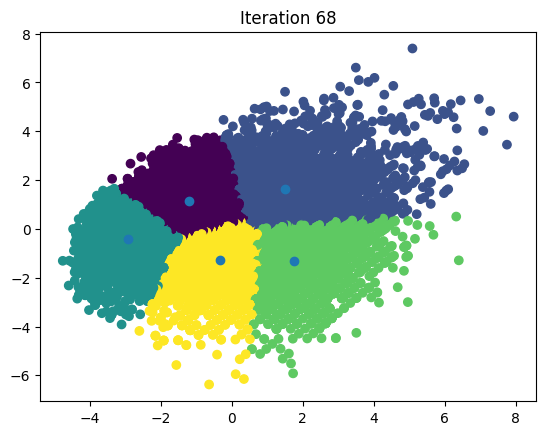

In [22]:
max_iterations=100
k=5

centroids=random_centroids(data,k)
old_centroids=pd.DataFrame()
iteration=1
while iteration<max_iterations and not centroids.equals(old_centroids):
      old_centroids=centroids

      labels=get_labels(data,centroids)
      centroids=new_centroids(data,labels,k)
      plot_clusters(data,labels,centroids,iteration)
      iteration+=1

In [23]:
centroids

,0,1,2,3,4
overall,4.244193,6.381714,2.479817,5.283515,4.151914
potential,5.933074,6.677009,4.385914,4.902698,4.159577
wage_eur,1.069213,1.632542,1.015604,1.175202,1.053546
value_eur,1.061292,1.413395,1.013117,1.058586,1.031386
age,2.569363,4.051314,2.307527,6.136680,4.466046


In [25]:
players[labels==2][["short_name"]+features]

,short_name,overall,potential,wage_eur,value_eur,age
12250,D. Ferdiz,63,63,500.0,500000.0,21
13640,Dêniro Prestes,62,62,2000.0,475000.0,21
13641,Raullino Meneses,62,62,2000.0,425000.0,21
14533,Túlio Nevinha,61,61,3000.0,350000.0,21
14583,J. Davies,61,67,500.0,525000.0,22
...,...,...,...,...,...,...
19234,Song Defu,47,52,1000.0,70000.0,22
19235,C. Porter,47,59,500.0,110000.0,19
19236,N. Logue,47,55,500.0,100000.0,21
19237,L. Rudden,47,60,500.0,110000.0,19


Now we can try how to implement knn directly from sklearn

In [27]:
from sklearn.cluster import KMeans

In [28]:
kmeans=KMeans(3)
kmeans.fit(data)

KMeans(n_clusters=3)

In [29]:
KMeans(n_clusters=3)

KMeans(n_clusters=3)

In [30]:
centroids=kmeans.cluster_centers_

In [31]:
pd.DataFrame(centroids,columns=features)

,overall,potential,wage_eur,value_eur,age
0,4.815008,4.513114,1.115124,1.040589,5.628127
1,6.200391,6.612842,1.645809,1.408051,4.098305
2,3.583251,5.188874,1.039043,1.035004,2.714686
